In [35]:
!pip install plotly


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
import pandas as pd # for data cleaning
import plotly.express as px # for data visualization
import plotly.graph_objects as go # for advance and customize graph help
import plotly.io as pio # helpful for graph templates
import plotly.colors as colors
pio.templates.default = "plotly_white" # for theme

In [37]:
data =pd.read_csv("Sample - Superstore.csv" , encoding = 'latin-1')

In [38]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [39]:
data.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [40]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

# converting date columns

In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [42]:
print(data['Order Date'].head())

0    11-08-2016
1    11-08-2016
2    06-12-2016
3    10-11-2015
4    10-11-2015
Name: Order Date, dtype: object


In [43]:
data['Order Date'] = pd.to_datetime(data['Order Date'])

ValueError: time data "4/15/2017" doesn't match format "%m-%d-%Y", at position 4. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [44]:
data['Order Date'] = data['Order Date'].str.replace('/', '-', regex=False) 

In [45]:
# Use dayfirst=True if your dash-based dates are in DD-MM-YYYY format
data['Order Date'] = pd.to_datetime(data['Order Date'], dayfirst=True, errors='coerce')

In [46]:
# Step 3: Verify the new dtype
print(data['Order Date'].dtype)


datetime64[ns]


In [47]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     4042 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   object        
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [48]:
data['Ship Date'] = data['Ship Date'].str.replace('/', '-', regex=False)

In [49]:
# Use dayfirst=True if your dash-based dates are in DD-MM-YYYY format
data['Ship Date'] = pd.to_datetime(data['Ship Date'], dayfirst=True, errors='coerce')

In [20]:
# Step 3: Verify the new dtype
print(data['Ship Date'].dtype)

datetime64[ns]


In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     4042 non-null   datetime64[ns]
 3   Ship Date      3898 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [22]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-12-06,NaT,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [52]:
data['order month'] = data['Order Date'].dt.month
data['order year'] = data['Order Date'].dt.year
data['order day of week'] = data['Order Date'].dt.dayofweek

In [53]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,order month,order year,order day of week
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,8.0,2016.0,3.0
1,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,8.0,2016.0,3.0
2,3,CA-2016-138688,2016-12-06,NaT,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,12.0,2016.0,1.0
3,4,US-2015-108966,2015-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,11.0,2015.0,1.0
4,5,US-2015-108966,2015-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,11.0,2015.0,1.0


# Monthly sales analysis

In [60]:
sales_by_month = data.groupby('order month')['Sales'].sum().reset_index()

In [61]:
sales_by_month

,order month,Sales
0,1.0,95524.5664
1,2.0,105139.1240
2,3.0,72319.9246
3,4.0,68162.3390
4,5.0,64520.5088
5,6.0,53306.8580
6,7.0,62610.9065
7,8.0,101577.9506
8,9.0,66582.3650
9,10.0,62993.8410


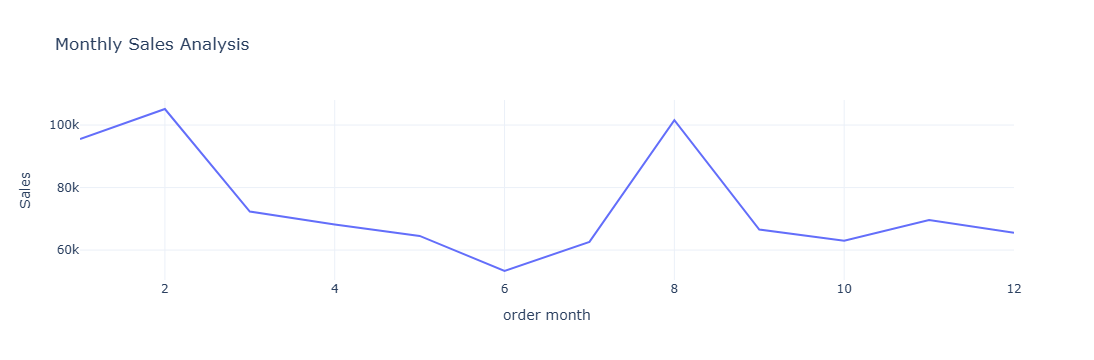

In [62]:
fig = px.line(sales_by_month,
             x='order month',
             y='Sales',
             title= 'Monthly Sales Analysis')
fig.show()

In [63]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,order month,order year,order day of week
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,8.0,2016.0,3.0
1,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,8.0,2016.0,3.0
2,3,CA-2016-138688,2016-12-06,NaT,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,12.0,2016.0,1.0
3,4,US-2015-108966,2015-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,11.0,2015.0,1.0
4,5,US-2015-108966,2015-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,11.0,2015.0,1.0


# sales by category

In [64]:
sales_by_category = data.groupby('Category')['Sales'].sum().reset_index()

In [65]:
sales_by_category

,Category,Sales
0,Furniture,741999.7953
1,Office Supplies,719047.0320
2,Technology,836154.0330


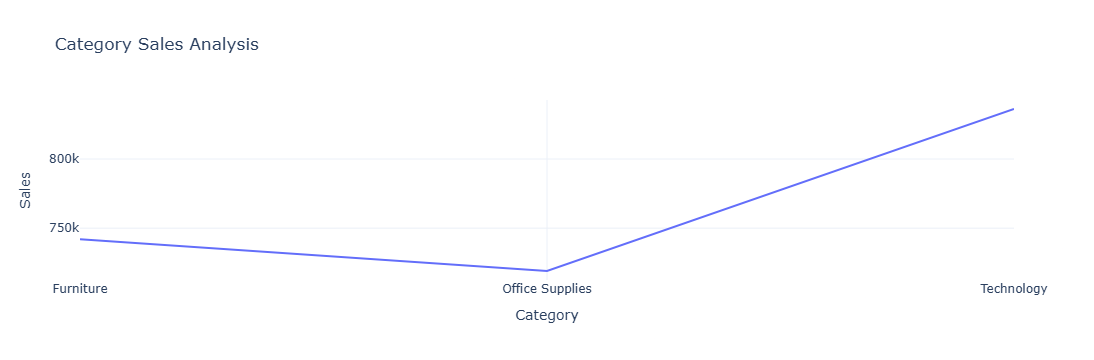

In [66]:
fig= px.line(sales_by_category,
             x= 'Category',
             y= 'Sales',
             title = 'Category Sales Analysis')
fig.show()

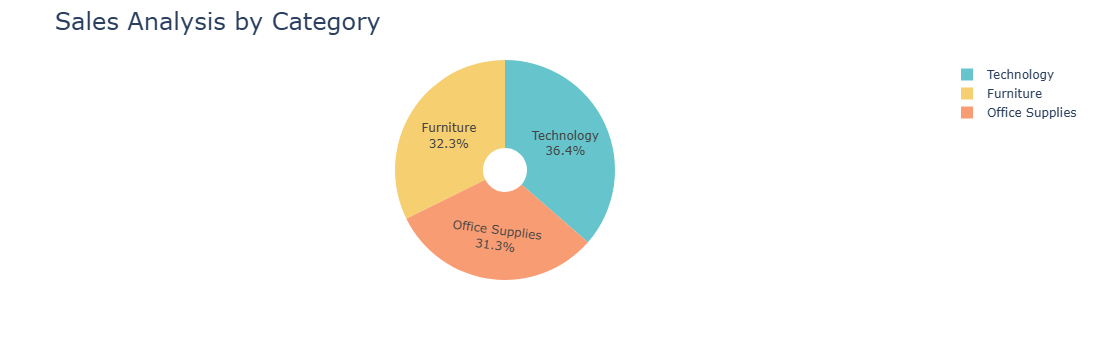

In [67]:
fig= px.pie(sales_by_category, 
            values = 'Sales',
            names = 'Category' ,
            hole =0.2,
            color_discrete_sequence= px.colors.qualitative.Pastel)
fig.update_traces(textposition='inside', textinfo= 'percent+label')
fig.update_layout(title_text='Sales Analysis by Category',title_font=dict(size=24))
fig.show()

# Sales analysis by Subcategory

In [68]:
sales_by_Subcategory = data.groupby('Sub-Category')['Sales'].sum().reset_index()

In [69]:
sales_by_Subcategory

,Sub-Category,Sales
0,Accessories,167380.3180
1,Appliances,107532.1610
2,Art,27118.7920
3,Binders,203412.7330
4,Bookcases,114879.9963
5,Chairs,328449.1030
6,Copiers,149528.0300
7,Envelopes,16476.4020
8,Fasteners,3024.2800
9,Furnishings,91705.1640


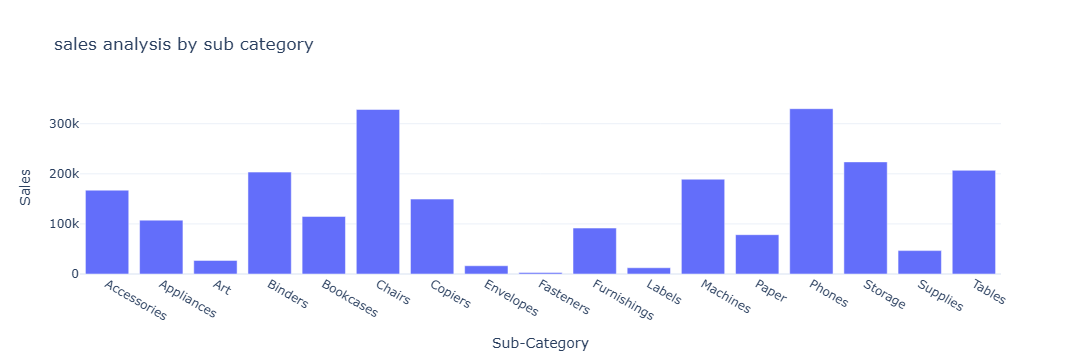

In [70]:
fig = px.bar(sales_by_Subcategory, x='Sub-Category', y='Sales', title= 'sales analysis by sub category')
fig.show()

# Monthly profit analysis

In [71]:
profit_by_month =data.groupby('order month')['Profit'].sum().reset_index()
profit_by_month

,order month,Profit
0,1.0,17006.7750
1,2.0,19441.0907
2,3.0,7090.5233
3,4.0,6873.6366
4,5.0,7498.2938
5,6.0,7489.6978
6,7.0,3773.0900
7,8.0,12088.5279
8,9.0,9917.1628
9,10.0,5315.2909


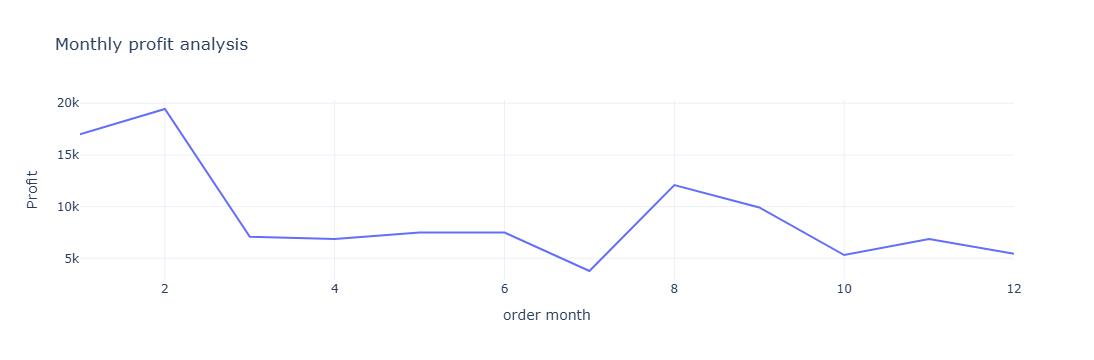

In [72]:
fig = px.line(profit_by_month,x='order month', y= 'Profit' , title= 'Monthly profit analysis')
fig.show()

# Profit by category

In [73]:
profit_by_category =data.groupby('Category')['Profit'].sum().reset_index()
profit_by_category

,Category,Profit
0,Furniture,18451.2728
1,Office Supplies,122490.8008
2,Technology,145454.9481


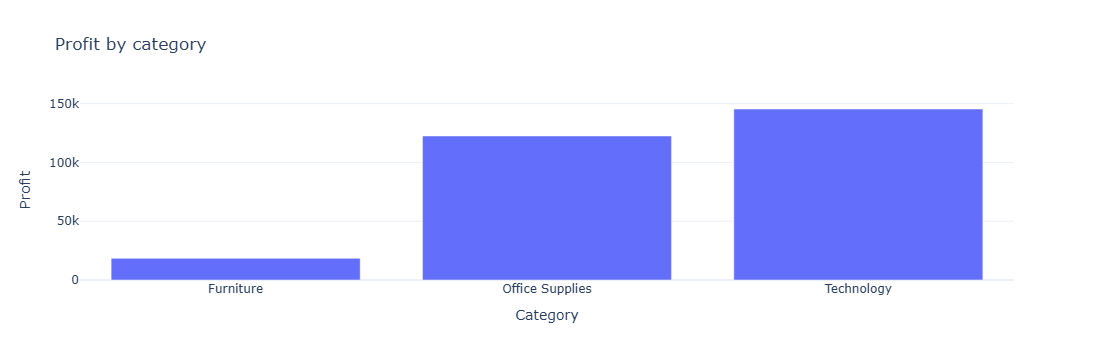

In [74]:
fig = px.bar(profit_by_category, x='Category', y='Profit', title = 'Profit by category')
fig.show()

In [75]:
profit_by_subcategory = data.groupby('Sub-Category')['Profit'].sum().reset_index()
profit_by_subcategory

,Sub-Category,Profit
0,Accessories,41936.6357
1,Appliances,18138.0054
2,Art,6527.7870
3,Binders,30221.7633
4,Bookcases,-3472.5560
5,Chairs,26590.1663
6,Copiers,55617.8249
7,Envelopes,6964.1767
8,Fasteners,949.5182
9,Furnishings,13059.1436


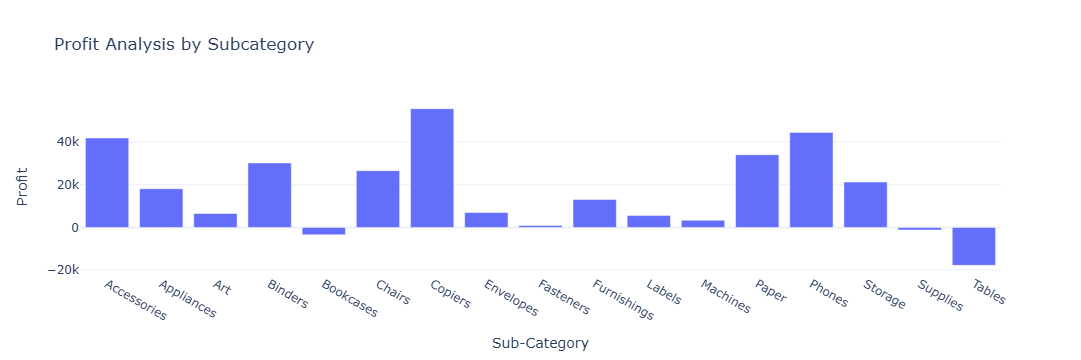

In [90]:
fig = px.bar(profit_by_subcategory, x='Sub-Category', y='Profit', title= 'Profit Analysis by Subcategory')
fig.show()

In [100]:
# This is pie chart but but its not showing good analysis so we make bar chart
''' fig = px.pie(profit_by_subcategory, values ='Profit', names= 'Sub-Category',
             hole= 0.2,
             color_discrete_sequence=px.colors.qualitative.Pastel)
fig.update_traces(textposition= 'inside', textinfo='percent+label')
fig.update_layout(title_text ='Profit Analysis by SubCategory', title_font=dict(size=24))
fig.show() '''

" fig = px.pie(profit_by_subcategory, values ='Profit', names= 'Sub-Category',\n             hole= 0.2,\n             color_discrete_sequence=px.colors.qualitative.Pastel)\nfig.update_traces(textposition= 'inside', textinfo='percent+label')\nfig.update_layout(title_text ='Profit Analysis by SubCategory', title_font=dict(size=24))\nfig.show() "

# sales and profit - customer segment

In [60]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,order month,order year,order day of week
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,8.0,2016.0,3.0
1,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,8.0,2016.0,3.0
2,3,CA-2016-138688,2016-12-06,NaT,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,12.0,2016.0,1.0
3,4,US-2015-108966,2015-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,11.0,2015.0,1.0
4,5,US-2015-108966,2015-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,11.0,2015.0,1.0


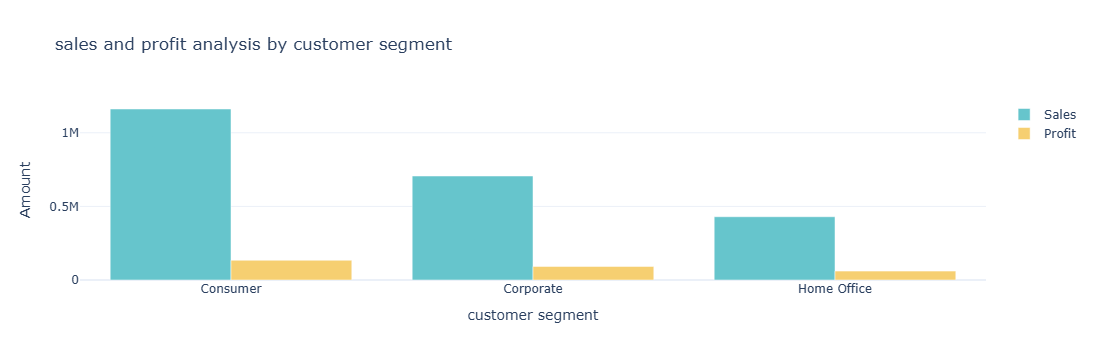

In [65]:
sales_profit_by_segment= data.groupby('Segment').agg({'Sales' :'sum', 'Profit' : 'sum'}).reset_index()
color_palette = colors.qualitative.Pastel
fig =go.Figure()
fig.add_trace(go.Bar(x=sales_profit_by_segment['Segment'],
                     y=sales_profit_by_segment['Sales'],
                     name ='Sales',
                     marker_color = color_palette[0]))
fig.add_trace(go.Bar(x=sales_profit_by_segment['Segment'],
                     y=sales_profit_by_segment['Profit'],
                     name ='Profit',
                     marker_color = color_palette[1]))
fig.update_layout(title= 'sales and profit analysis by customer segment', 
                 xaxis_title = 'customer segment', yaxis_title='Amount')
fig.show()
            


# Sales to profit ratio 

In [102]:
sales_profit_by_segment= data.groupby('Segment').agg({'Sales':'sum', 'Profit':'sum'}).reset_index()
sales_profit_by_segment['Sales_to_profit_ratio']= sales_profit_by_segment['Sales'] / sales_profit_by_segment['Profit']
print(sales_profit_by_segment[['Segment', 'Sales_to_profit_ratio']])

       Segment  Sales_to_profit_ratio
0     Consumer               8.659471
1    Corporate               7.677245
2  Home Office               7.125416
